In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
mintues=np.array([60, 90, 90, 120, 240])
np.mean(mintues)
np.median(mintues)
np.var(mintues)
np.std(mintues)

np.float64(62.928530890209096)

# Probablity Mass Function

In [3]:
# Rolling one dice
L=[]
for i in range(10000):
    a=random.randint(1,6)
    L.append(a)




In [4]:
series=pd.Series(L)

In [5]:
probablities=(series.value_counts()/series.value_counts().sum()).sort_index()

<Axes: >

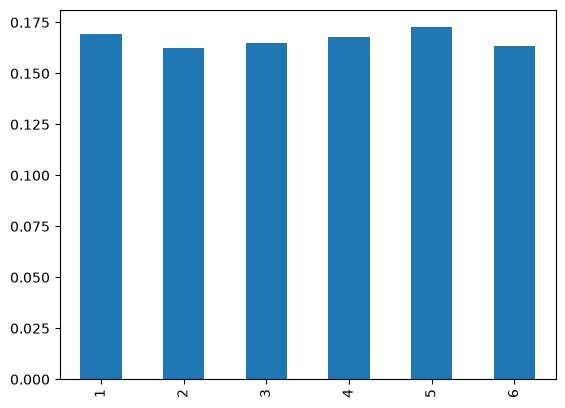

In [6]:
probablities.plot(kind='bar')

In [7]:
# Rolling two dice and probablity of their sum
l=[]
for i in range(10000):
    a=random.randint(1,6)
    b=random.randint(1,6)

    l.append(a+b)

In [8]:
two_dice_series=pd.Series(l)
probablities_two_dice=two_dice_series.value_counts().sort_index()/two_dice_series.value_counts().sum()

<Axes: >

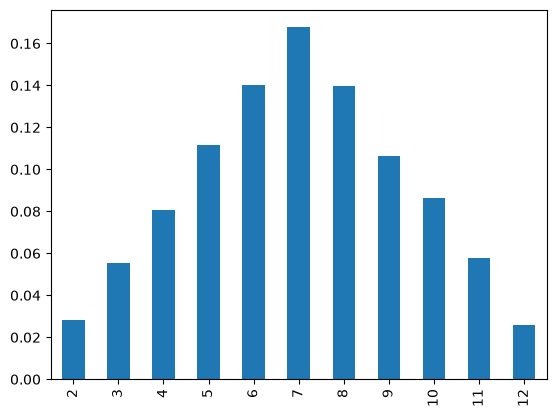

In [9]:
probablities_two_dice.plot(kind='bar')

# Cumulative Distribution Function

<Axes: >

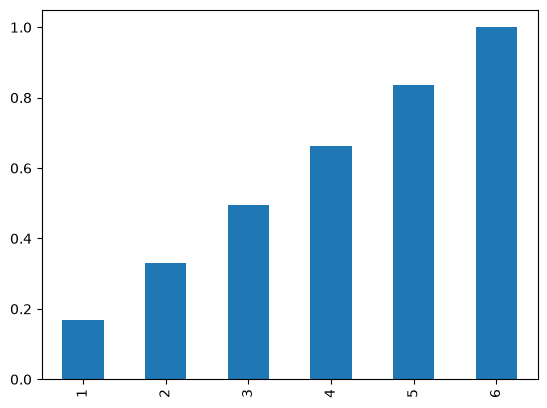

In [10]:
# For one dice
np.cumsum(probablities).plot(kind='bar')

<Axes: >

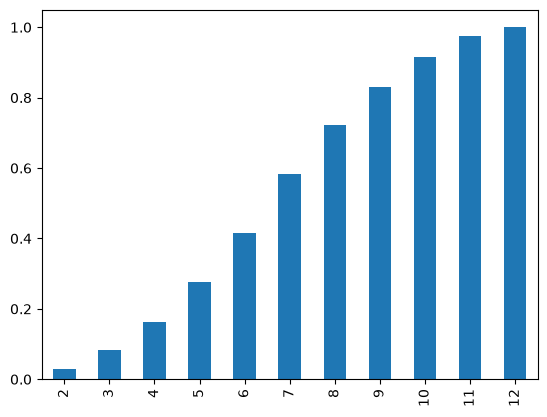

In [11]:
np.cumsum(probablities_two_dice).plot(kind='bar')

# Probability Density Function

Parametric Density Estimation

In [5]:
from numpy.random import normal

sample=normal(loc=50,scale=5,size=1000)

In [6]:
sample_mean=sample.mean()
sample_std=sample.std()

In [7]:
from scipy.stats import norm

dist=norm(sample_mean,sample_std)

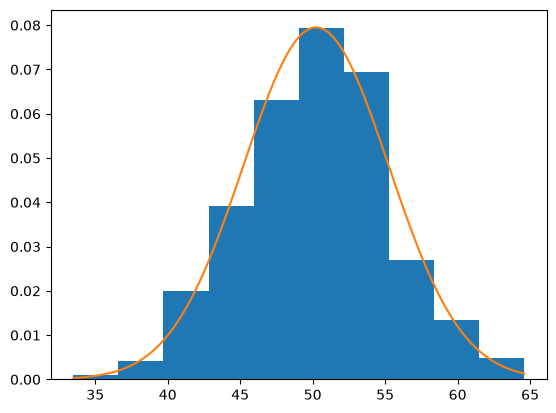

In [32]:
values=np.linspace(sample.min(),sample.max(),100)
probablities=[dist.pdf(value) for value in values]

plt.hist(sample,bins=10,density=True)
plt.plot(values,probablities)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3184\3311749440.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  snc.distplot(sample)


<Axes: ylabel='Density'>

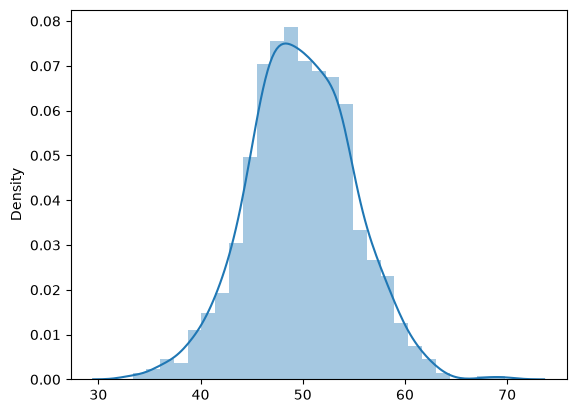

In [8]:
import seaborn as snc

snc.distplot(sample)

# Kernel Density Estimation

In [42]:
sample1=normal(loc=40,scale=5,size=700)
sample2=normal(loc=20,scale=5,size=300)
sample=np.hstack((sample1,sample2))

(array([ 17.,  43., 110.,  86.,  50., 105., 237., 233.,  97.,  22.]),
 array([ 6.67923667, 11.40317038, 16.12710409, 20.85103781, 25.57497152,
        30.29890523, 35.02283894, 39.74677265, 44.47070637, 49.19464008,
        53.91857379]),
 <BarContainer object of 10 artists>)

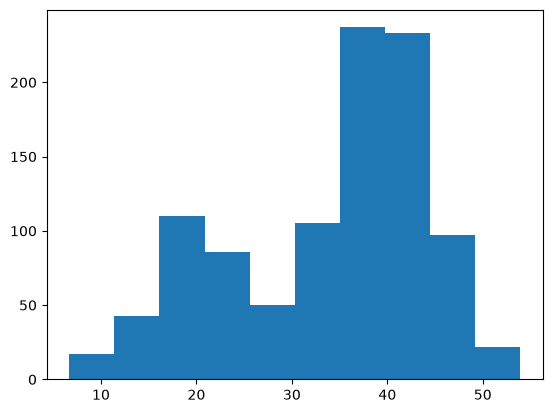

In [43]:
plt.hist(sample)

In [9]:
from sklearn.neighbors import KernelDensity

model=KernelDensity(bandwidth=3,kernel='gaussian')

sample=sample.reshape(-1,1)

model.fit(sample)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,3


In [53]:
values=np.linspace(sample.min(),sample.max(),100)
values=values.reshape(-1,1)

In [54]:
probablities=model.score_samples(values)
probablities=np.exp(probablities)

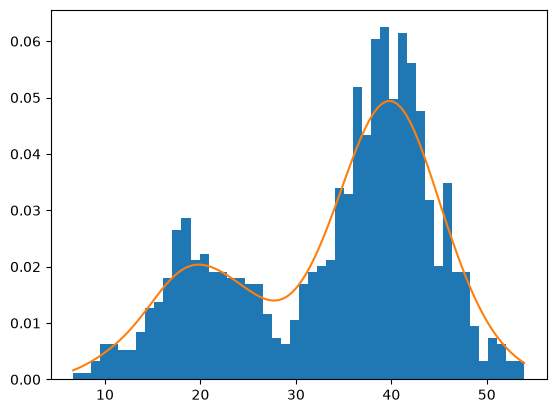

In [58]:
plt.hist(sample,bins=50,density=True)
plt.plot(values[:],probablities)

<Axes: ylabel='Density'>

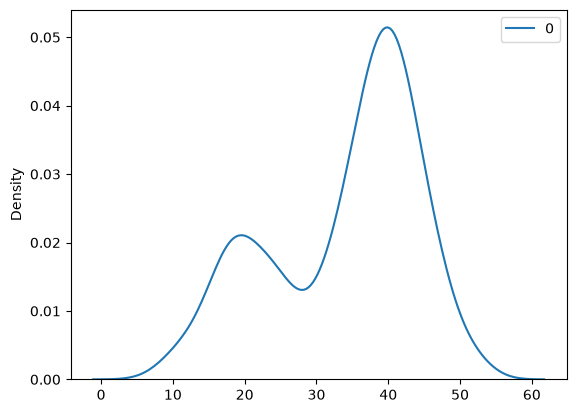

In [65]:
snc.kdeplot(sample)

In [115]:
insurance=pd.read_csv('insurance_data - insurance_data.csv')
insurance['age']=insurance['age'].fillna(insurance['age'].median())

### Q-1: What is the probability distribution of age in the insurance dataset?

-- Find out using the KDE method

<Axes: xlabel='age', ylabel='Density'>

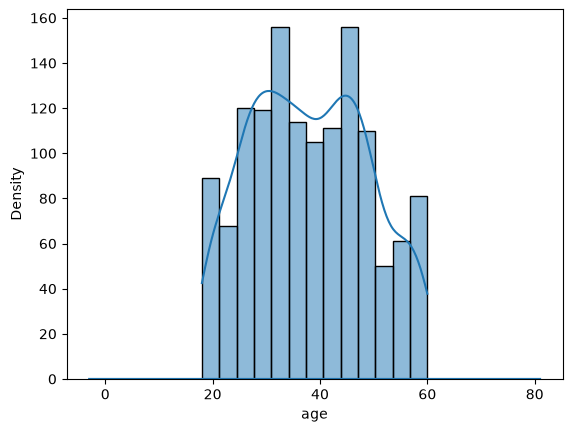

In [130]:
insurance['age'].plot(kind='kde')
snc.histplot(insurance['age'],kde=True)

In [126]:
model=KernelDensity(bandwidth=3,kernel='gaussian')

model.fit(insurance['age'].to_numpy().reshape(-1,1))

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,3


In [127]:
values=np.linspace(insurance['age'].min(),insurance['age'].max(),100)
values=values.reshape(-1,1)

In [128]:
probablities=model.score_samples(values)
probablities=np.exp(probablities)

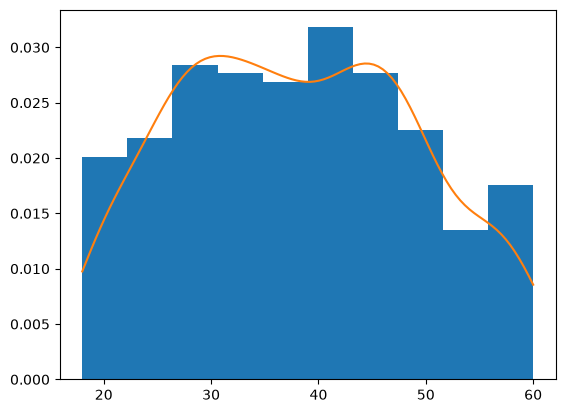

In [129]:
plt.hist(insurance['age'],bins=10,density=True)
plt.plot(values[:],probablities)

<Axes: xlabel='age', ylabel='Density'>

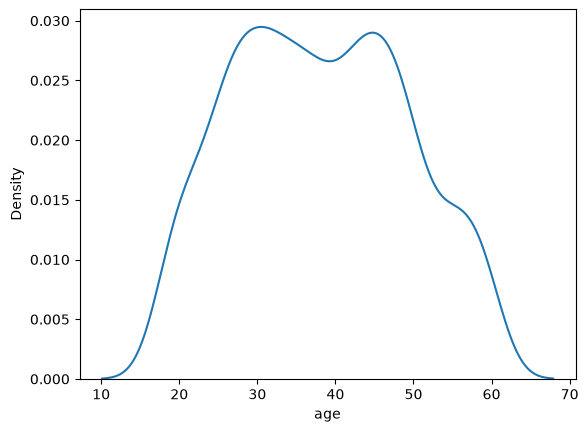

In [131]:
snc.kdeplot(insurance['age'])

# Q-2: What is the probability of a patient having a BMI greater than 30?

In [142]:
total_people=len(insurance)
people_having_30_bmi=len(insurance[insurance['bmi']>30])

probability=people_having_30_bmi/total_people
probability

0.5216417910447761

# Q-3: Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

<Axes: xlabel='claim', ylabel='Count'>

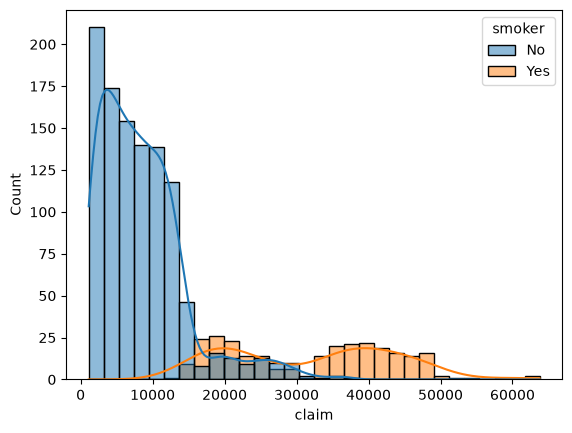

In [159]:
snc.histplot(data=insurance,x='claim',hue='smoker',kde=True)

# Q-4: Plot the 2D probability density plot of claim and age in the insurance dataset?

<Axes: xlabel='age', ylabel='claim'>

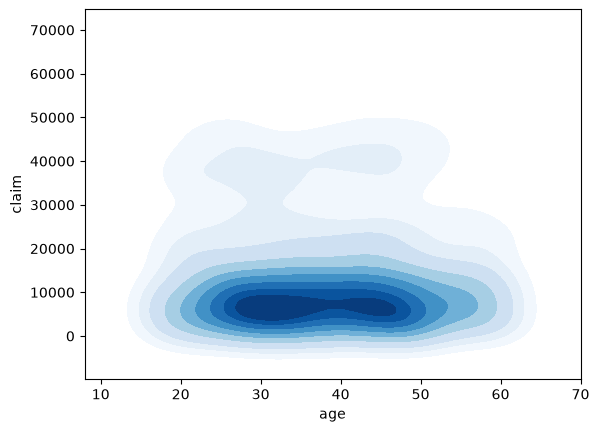

In [166]:
snc.kdeplot(data=insurance,y='claim',x='age',cmap='Blues',thresh=0.05,fill=True)

#  Q5. How does the disribution of claim changes for different region? Plot density plot and note down the observations

<Axes: xlabel='claim', ylabel='Density'>

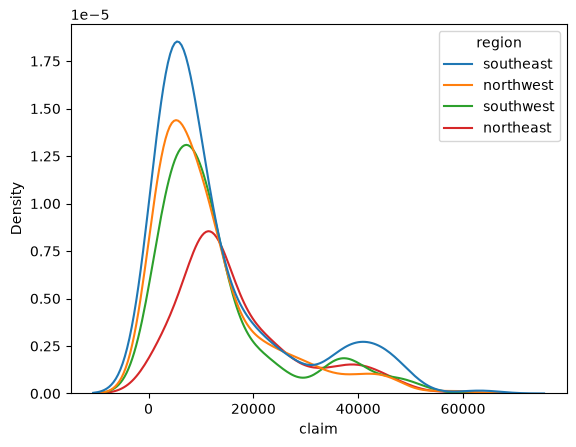

In [162]:
snc.kdeplot(data=insurance,x='claim',hue='region')

# Plot PDF and CDF of claim in insurance data

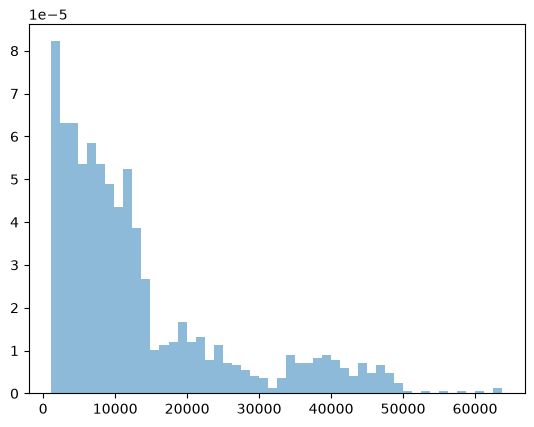

In [171]:
claim_data=insurance.claim
plt.hist(claim_data,density=True, alpha=0.5,bins=50)
plt.show()

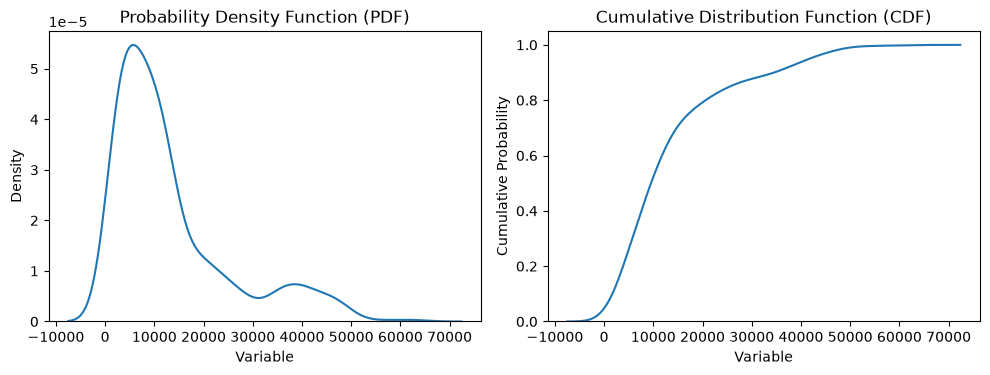

In [182]:
data=claim_data

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
snc.kdeplot(data)
plt.xlabel('Variable')
plt.ylabel('Density')
plt.title('Probability Density Function (PDF)')

plt.subplot(1,2,2)
snc.kdeplot(data,cumulative=True)
plt.xlabel('Variable')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF)')

plt.tight_layout()
plt.show()

# Q-7: Given a probability density function f(x) = 2x for 0 <= x <= 1 and f(x) = 0 otherwise, compute the cumulative distribution function F(x) and plot it. Use this to find the probability that X is greater than 0.5.


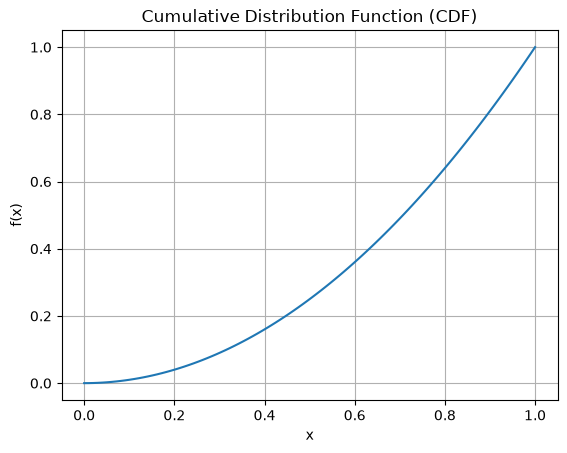

Probability X > 0.5: 0.75


In [200]:
def pdf(x):
    if 0<=x<=1:
        return 2*x
    else:
        return 0
    
def cdf(x):
    if x<0:
        return 0
    
    elif 0<=x<=1:
        return x**2
    
    else:
        return 1
    
values=np.linspace(0,1,100)
# CDF 
y_cdf=np.array([cdf(val)  for val in values])

plt.plot(values,y_cdf)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

prob_greater_than_05 = 1 - cdf(0.5)
print(f"Probability X > 0.5: {prob_greater_than_05}")

# Q-8: In a manufacturing process, the thickness of a certain material is known to be normally distributed with a mean of 1.2 mm and a standard deviation of 0.05 mm. What is the probability density function of the thickness? Plot the PDF and use it to compute the probability that the thickness is between 1.1 mm and 1.3 mm.

The probability density function (PDF) of a normal distribution with mean μ and standard deviation σ is given by:

f(x) = (1 / (σ * sqrt(2 * π))) * exp(-(x - μ)^2 / (2 * σ^2))

np.float64(0.9544997361036416)

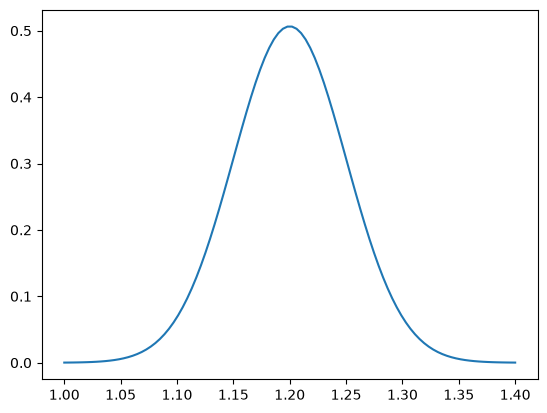

In [34]:
def pdf(x,mean,std):
    return (1/(std*np.square(2*np.pi)))*np.exp(-(x-mean)**2/(2*std**2))

dist=norm(1.2,0.05)
values=np.linspace(1.0,1.4,100)
y_pdf=pdf(values,1.2,0.05)

# probablities=dist.pdf(values)

cdf=dist.cdf(1.3)-dist.cdf(1.1)
plt.plot(values,y_pdf)

cdf


# Q-8 : A data scientist is investigating the distribution of customer ages in a retail store. She collects a sample of 100 ages and estimates the probability density function using kernel density estimation. What bandwidth should she choose to obtain the best estimate?

#### Solution:

Choosing the best bandwidth for KDE involves finding a balance between overfitting and underfitting. If the bandwidth is too small, the estimated PDF may have a lot of small, spurious oscillations or noise, which may not accurately represent the underlying distribution of the data. On the other hand, if the bandwidth is too large, the estimated PDF may be overly smooth and may not capture the finer details or variations in the data.

There are several methods that can be used to select the optimal bandwidth for KDE, including cross-validation, rule-of-thumb methods (e.g., Scott's rule, Silverman's rule), and optimization techniques (e.g., maximum likelihood estimation).

One common rule-of-thumb method for choosing the bandwidth in KDE is Scott's rule, which is given by:

`h = 1.06 * sigma * n^(-1/5)`

where `h` is the bandwidth, sigma is the standard deviation of the data, and `n` is the number of data points in the sample. Scott's rule is often used as a default bandwidth choice in many KDE implementations.

In [35]:
# Scott's Approach
best_bandwith=1.06*10*(100**(-1/5))
best_bandwith

4.219936007867071

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

ages = np.random.normal(loc=40, scale=10, size=100)

bandwidths = 10 ** np.linspace(-1, 1, 100)

params = {'bandwidth': bandwidths, 'kernel': ['gaussian']}

grid = GridSearchCV(KernelDensity(), params, cv=5)
grid.fit(ages.reshape(-1, 1))

best_bandwidth = grid.best_estimator_.bandwidth
print('Best bandwidth:', best_bandwidth)


Best bandwidth: 5.214008287999687


In [125]:
np.random.randint(0,2,100)

array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1], dtype=int32)

# Binomial Distribution

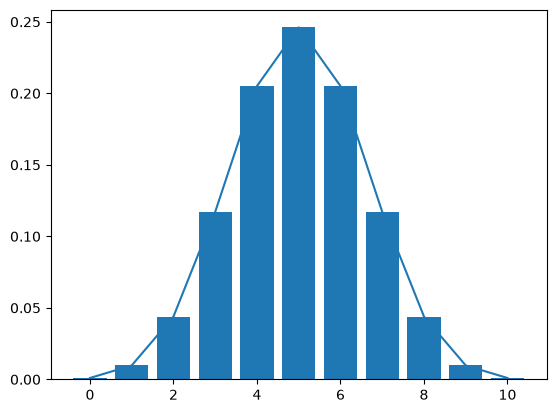

In [176]:
import math

def combinations(n, k):
    return math.factorial(n) / (math.factorial(k) * math.factorial(n - k))


def binomial_probability(n, k, p):
 
    paths = combinations(n, k)
    

    prob_success = p ** k
    prob_failure = (1 - p) ** (n - k)
    

    total_probability = paths * prob_success * prob_failure
    return total_probability


n_tosses = 10
k_heads = np.array([0,1,2,3,4,5,6,7,8,9,10])
p_head = 0.5

probability = np.array([binomial_probability(n_tosses, val, p_head) for val in k_heads])

plt.bar(k_heads,probability)
plt.plot(k_heads,probability)

# Poisson Distribution

### f(x)=(lamda^x)*(e**-lambda)/x!

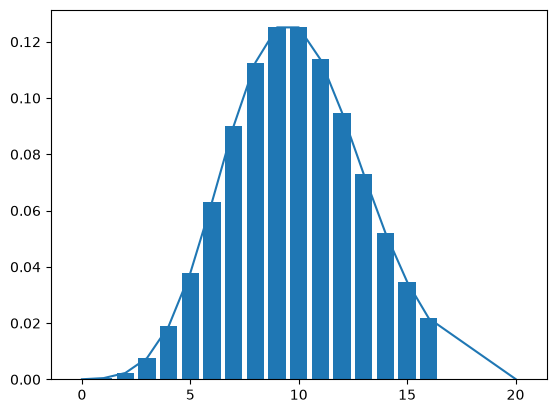

In [177]:
# Average no: of calls in a hour for a call center is 10(lambda=10)
# Using this data to find probabilties of different no: of calls

import math

def poisson_probability_for_call_center(X):
    return (10**X)*(np.e**-10)/math.factorial(X)


poisson_probability_for_call_center(6)
calls=np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,20])

probablities=[poisson_probability_for_call_center(call) for call in calls]
plt.bar(calls,probablities)
plt.plot(calls,probablities)

# Pareto Distribution

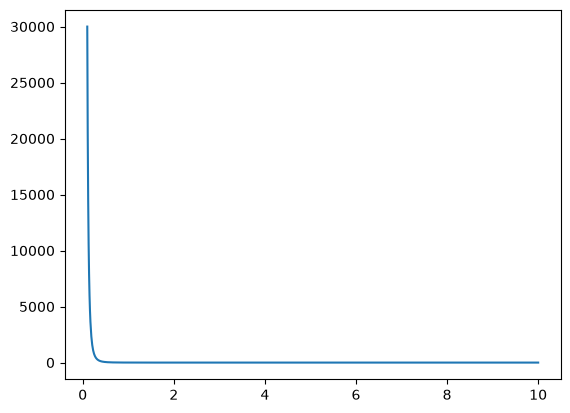

In [178]:
# Define the parameters of the Pareto distribution
alpha = 3
xm = 1

# Create an array of x values
x = np.linspace(0.1, 10, 1000)

# Calculate the y values of the Pareto distribution
y = alpha * (xm**alpha) / (x**(alpha+1))


plt.plot(x,y)

# LOG-LOG Plot. 

### It helps in detecting whether a distribution is pareto distribution or not

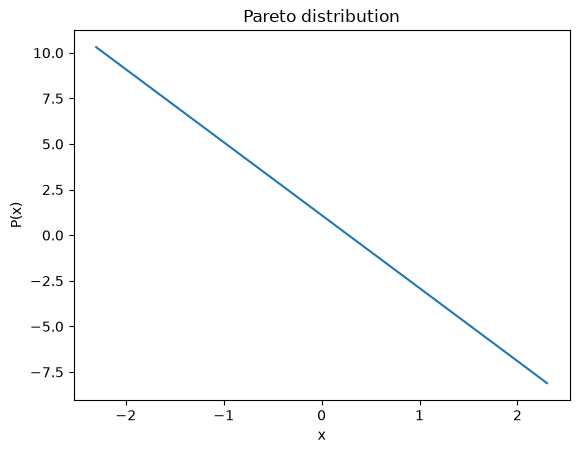

In [179]:
# Create the log-log plot
plt.plot(np.log(x),np.log(y))

# Add labels and a title
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Pareto distribution')

# Show the plot
plt.show()

# QQ Plot

(array([975.,  16.,   4.,   0.,   1.,   1.,   0.,   1.,   1.,   1.]),
 array([ 1.00052481,  5.95041577, 10.90030673, 15.85019768, 20.80008864,
        25.74997959, 30.69987055, 35.6497615 , 40.59965246, 45.54954342,
        50.49943437]),
 <BarContainer object of 10 artists>)

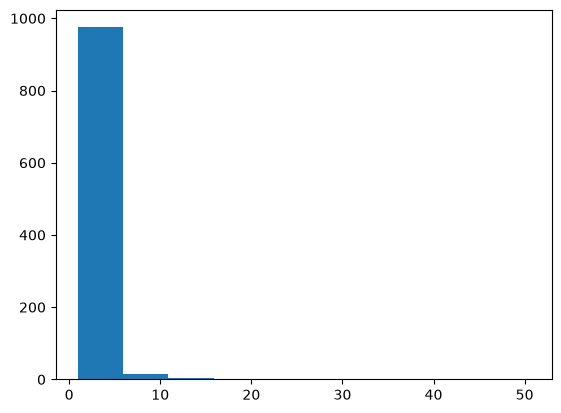

In [187]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 2
xm = 1

# Generate a set of random data from the Pareto distribution
x = stats.pareto.rvs(b=alpha, scale=xm, size=1000)

plt.hist(x)



In [189]:
# Fit a Pareto distribution to the data
params = stats.pareto.fit(x, floc=0)

# Create a Pareto distribution object with the fitted parameters
dist = stats.pareto(b=params[0], scale=params[2])

dist

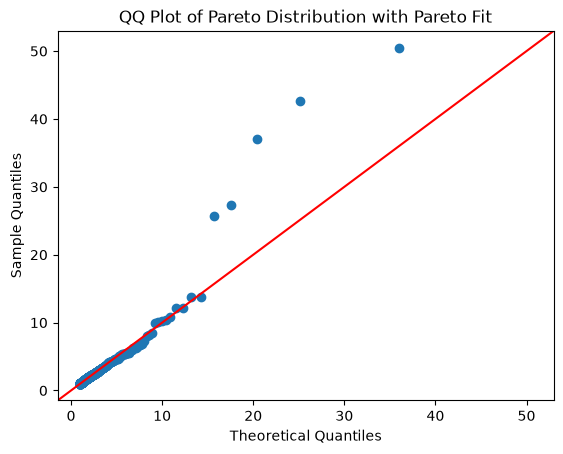

In [190]:
# Create a QQ plot of the data using the Pareto distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title and labels to the plot
plt.title('QQ Plot of Pareto Distribution with Pareto Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()

# Tasks on Normal Distribution

### `Q.1`. Given a normal distribution with mean as 50 and deviation as 10, answer below questions

(X ~ N(5O, 10) ): 

    a. what are the values of the mean and standard deviation? 
    
    b. What value of x has a z-score of 1.4? 

    c. What is the Z-score that corresponds to x = 30? 

    d. What is the difference between positive and negative z values?

### Solution

`a.` The mean of the normal distribution is 5O, and the standard deviation is 10.

`b.` To find the value of x that corresponds to a z-score of 1.4, we use the formula for converting z-scores to raw scores (x):

z = (x - μ) / σ

where μ is the mean and σ is the standard deviation. Rearranging the formula, we have:

x = z * σ + μ

Substituting z = 1.4, μ = 50, and σ = 10, we get:

x = 1.4 * 10 + 50 = 64

Therefore, the value of x that has a z-score of 1.4 is 64.

`c.` To find the z-score that corresponds to x = 30, we use the same formula as in part (b), but solve for z:

z = (x - μ) / σ

Substituting x = 30, μ = 50, and σ = 10, we get:

z = (30 - 50) / 10 = -2

Therefore, the z-score that corresponds to x = 30 is -2.

`d.` The sign of the z-score indicates whether the raw score (x) is above or below the mean of the distribution. A positive z-score indicates that the raw score is above the mean, while a negative z-score indicates that the raw score is below the mean. The absolute value of the z-score represents the number of standard deviations away from the mean.

In [192]:
nd=normal(50,10,1000)

In [195]:
nd.mean()
nd.std()

np.float64(9.843552272127585)

In [210]:
# z=x-mean/std -> x=z*std+mean
(1.4*nd.std())+nd.mean()

np.float64(64.26292124603746)

In [208]:
z=(30-nd.mean())/nd.std()

In [209]:
z

np.float64(-2.0807476304112598)

<Axes: ylabel='Density'>

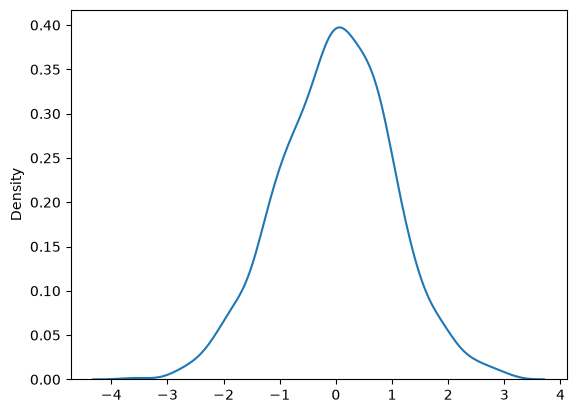

In [200]:
snc.kdeplot(z)

### `Q.2:`The average test score in a certain statistics class was 74 with a standard deviation of 8. There are 2000 students in this class. Use the emperical rule to answer the following questions: 
    (a) What percentage of students scored less than 58? 
    (b) What is the probability that a student score between 66 and 82 on the exam? 
    (c) How many students scored at most 90? 
    (d) What percentage of students scored at least 66? 
    (e) How many students scored more than 98 on the test?


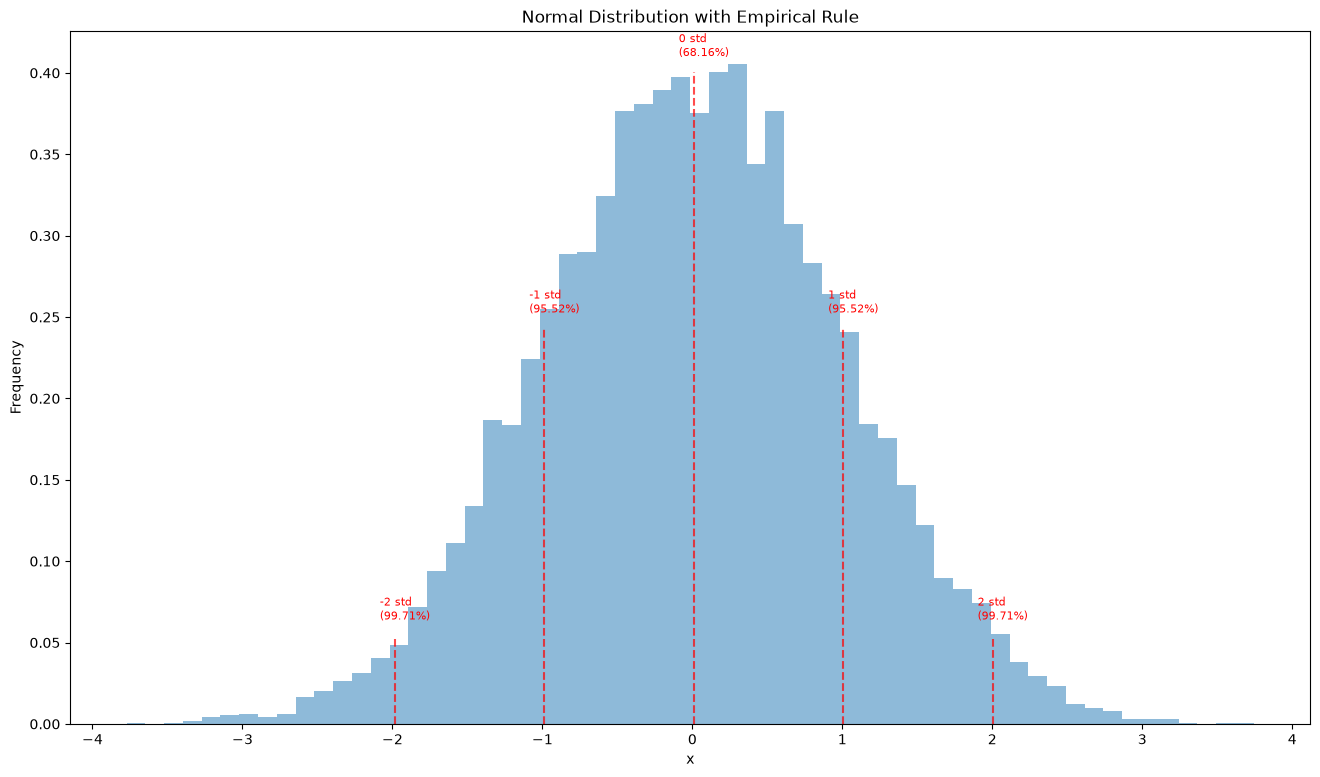

In [223]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some normally distributed data
mu = 0
sigma = 1
data = np.random.normal(mu, sigma, size=10000)

# Compute the mean and standard deviation of the data
mean = np.mean(data)
std = np.std(data)

# Compute the percentages for each standard deviation
pct_0 = round(((np.sum((data >= mean - std) & (data <= mean + std))) / len(data)) * 100, 2)
pct_1 = round(((np.sum((data >= mean - 2*std) & (data <= mean + 2*std))) / len(data)) * 100, 2)
pct_2 = round(((np.sum((data >= mean - 3*std) & (data <= mean + 3*std))) / len(data)) * 100, 2)

fig = plt.figure(figsize=(16, 9))

# Plot the histogram of the data
plt.hist(data, bins=60, density=True, alpha=0.5)

# Plot the empirical rule lines with markers and percentages
for i in range(-2, 3):
    x = mean + i*std
    y = 1/(np.sqrt(2*np.pi)*std)*np.exp(-(x-mean)**2/(2*std**2))
    plt.plot([x, x], [0, y], linestyle='--', color='r', alpha=0.7)
    plt.annotate(f"{i} std\n({eval(f'pct_{abs(i)}')}%)", (x, y), xytext=(x-0.1, y+0.01), fontsize=8, color='r')

# Add labels and a title to the plot
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('Normal Distribution with Empirical Rule')

# Show the plot
plt.show()




`Given:`

Mean score (μ) = 74

Standard deviation (σ) = 8

Number of students (N) = 2000

The empirical rule states that for a normal distribution, approximately:

* 68% of the data falls within one standard deviation of the mean (i.e., μ ± σ)
* 95% of the data falls within two standard deviations of the mean (i.e., μ ± 2σ)
* 99.7% of the data falls within three standard deviations of the mean (i.e., μ ± 3σ)

Using the empirical rule, we can answer the following questions:

##### `(a) What percentage of students scored less than 58?`

Find the z-score of 58:

z = (58 - 74) / 8 = -2

The percentage of students who scored less than 58 is the same as the percentage of students who are more than 2 standard deviations below the mean, which is approximately:

P(z < -2) = P(z > 2) = 0.0228

Therefore, approximately 2.28% of the students scored less than 58.

##### `(b) What is the probability that a student scores between 66 and 82 on the exam?`

Find the z-scores of 66 and 82:
z1 = (66 - 74) / 8 = -1
z2 = (82 - 74) / 8 = 1
The probability of a student scoring between 66 and 82 is the same as the probability of being within one standard deviation of the mean, which is approximately:
P(-1 < z < 1) = 0.68
Therefore, approximately 68% of the students scored between 66 and 82.

#####`(c) How many students scored at most 90?`

Find the z-score of 90:

z = (90 - 74) / 8 = 2

The percentage of students who scored at most 90 is the same as the percentage of students who are less than or equal to 2 standard deviations above the mean, which is approximately:

P(z <= 2) = 0.9772

Therefore, approximately 1954 students scored at most 90 (out of 2000 students).

#####`(d) What percentage of students scored at least 66?`

Find the z-score of 66:
z = (66 - 74) / 8 = -1
The percentage of students who scored at least 66 is the same as the percentage of students who are at most 1 standard deviation below the mean, which is approximately:
P(z >= -1) = 0.8413
Therefore, approximately 84.13% of the students scored at least 66.

#####`(e) How many students scored more than 98 on the test?`

Find the z-score of 98:

z = (98 - 74) / 8 = 3

The percentage of students who scored more than 98 is the same as the percentage of students who are more than 3 standard deviations above the mean, which is approximately:

P(z > 3) = 0.0013

Therefore, approximately 1.3 students scored more than 98 (out of 2000 students). However, since we cannot have a fraction of a student, we can say that either 1 or 2 students scored more than 98.

### `Q-3`: Wine data
```
# Load dataset
import pandas as pd
from sklearn.datasets import load_wine

# load the wine dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

```
Consider this "wine" dataset which can be loaded using above code. It has 13 numerical features and a target column with 3 class: 0, 1, 2. 


* **Which feature is the best predictor of the wine class in the wine dataset?** (Using pdf plot)

* **Which two combination of features from below listed features are best for wine classification?** (2D pdf plot)
    * Proline
    * Flavanoids
    * Color intensity
    * OD280/OD315 of diluted wines
    * Alcohol

In [229]:

import pandas as pd
from sklearn.datasets import load_wine
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

In [228]:
data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

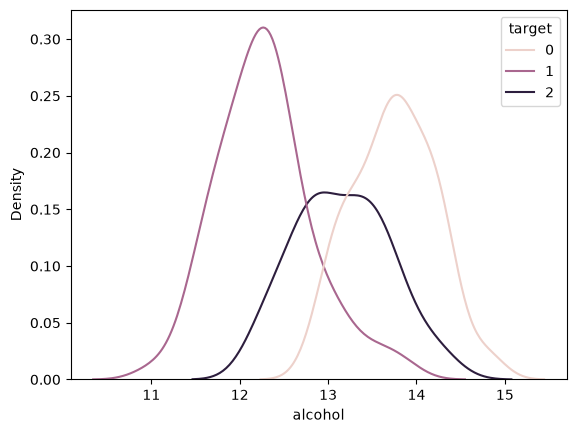

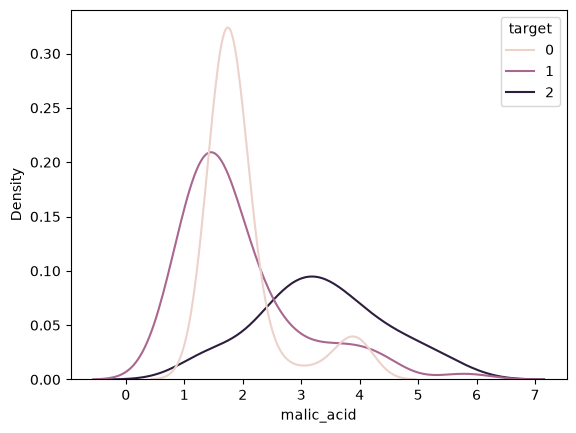

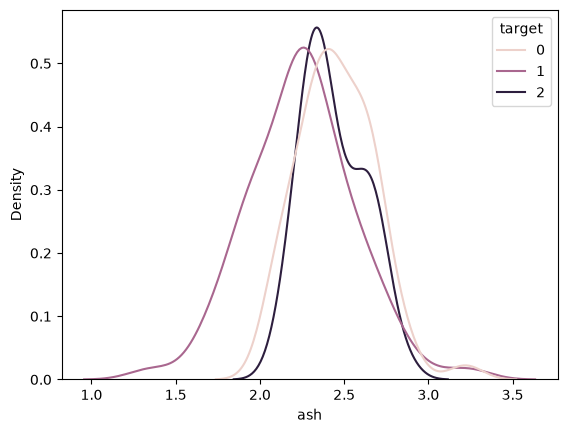

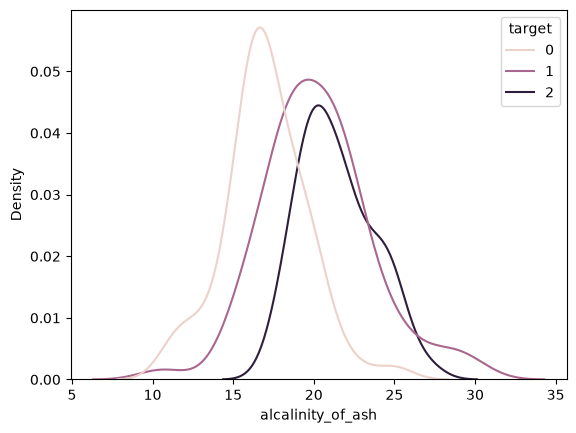

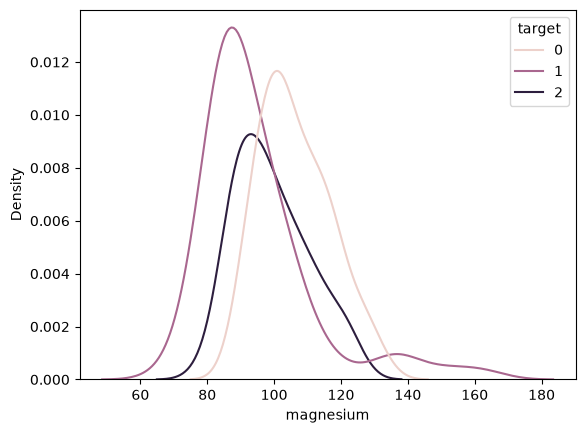

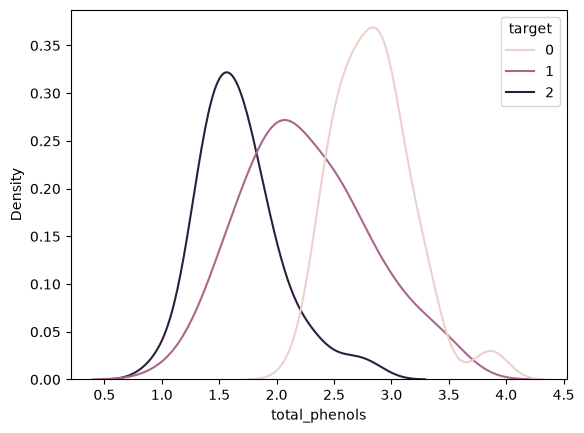

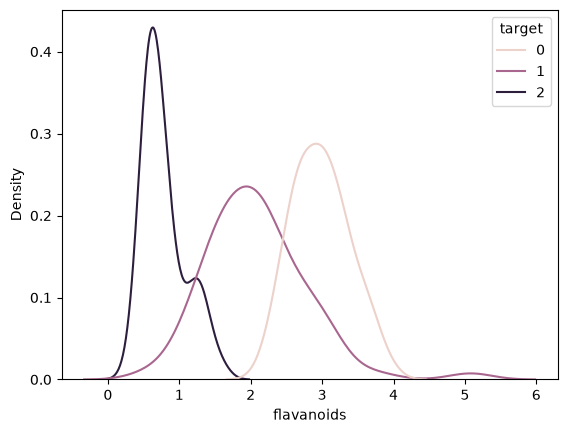

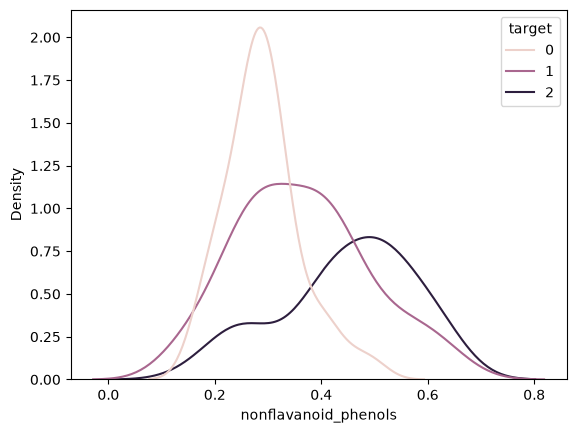

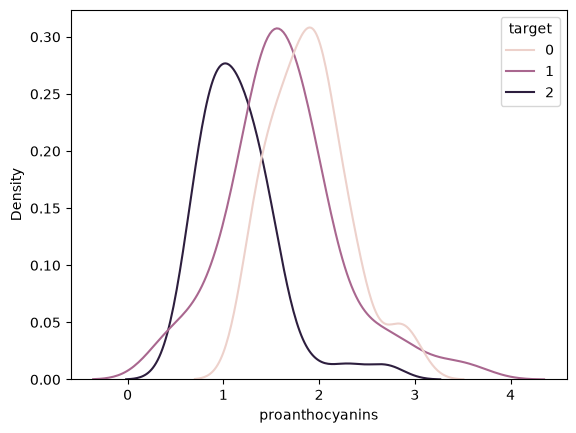

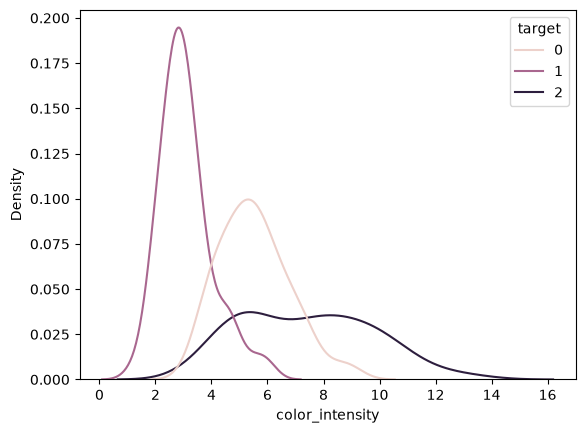

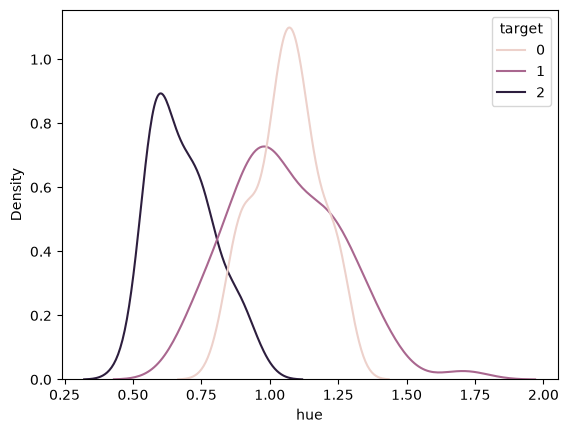

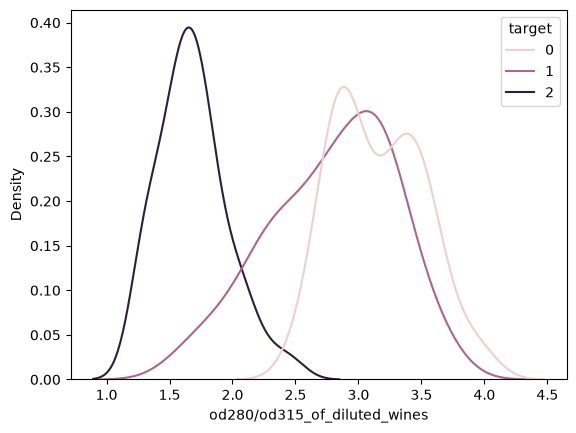

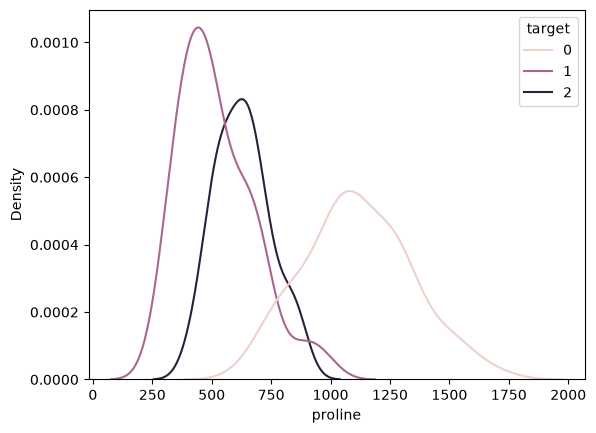

In [ ]:
for column in data.feature_names:
    snc.kdeplot(data=df,x=column,hue='target')
    plt.show()

# Based on PDF plots, Flavanoids column is best feature
# PDF of this feature for different classes are less overlapping

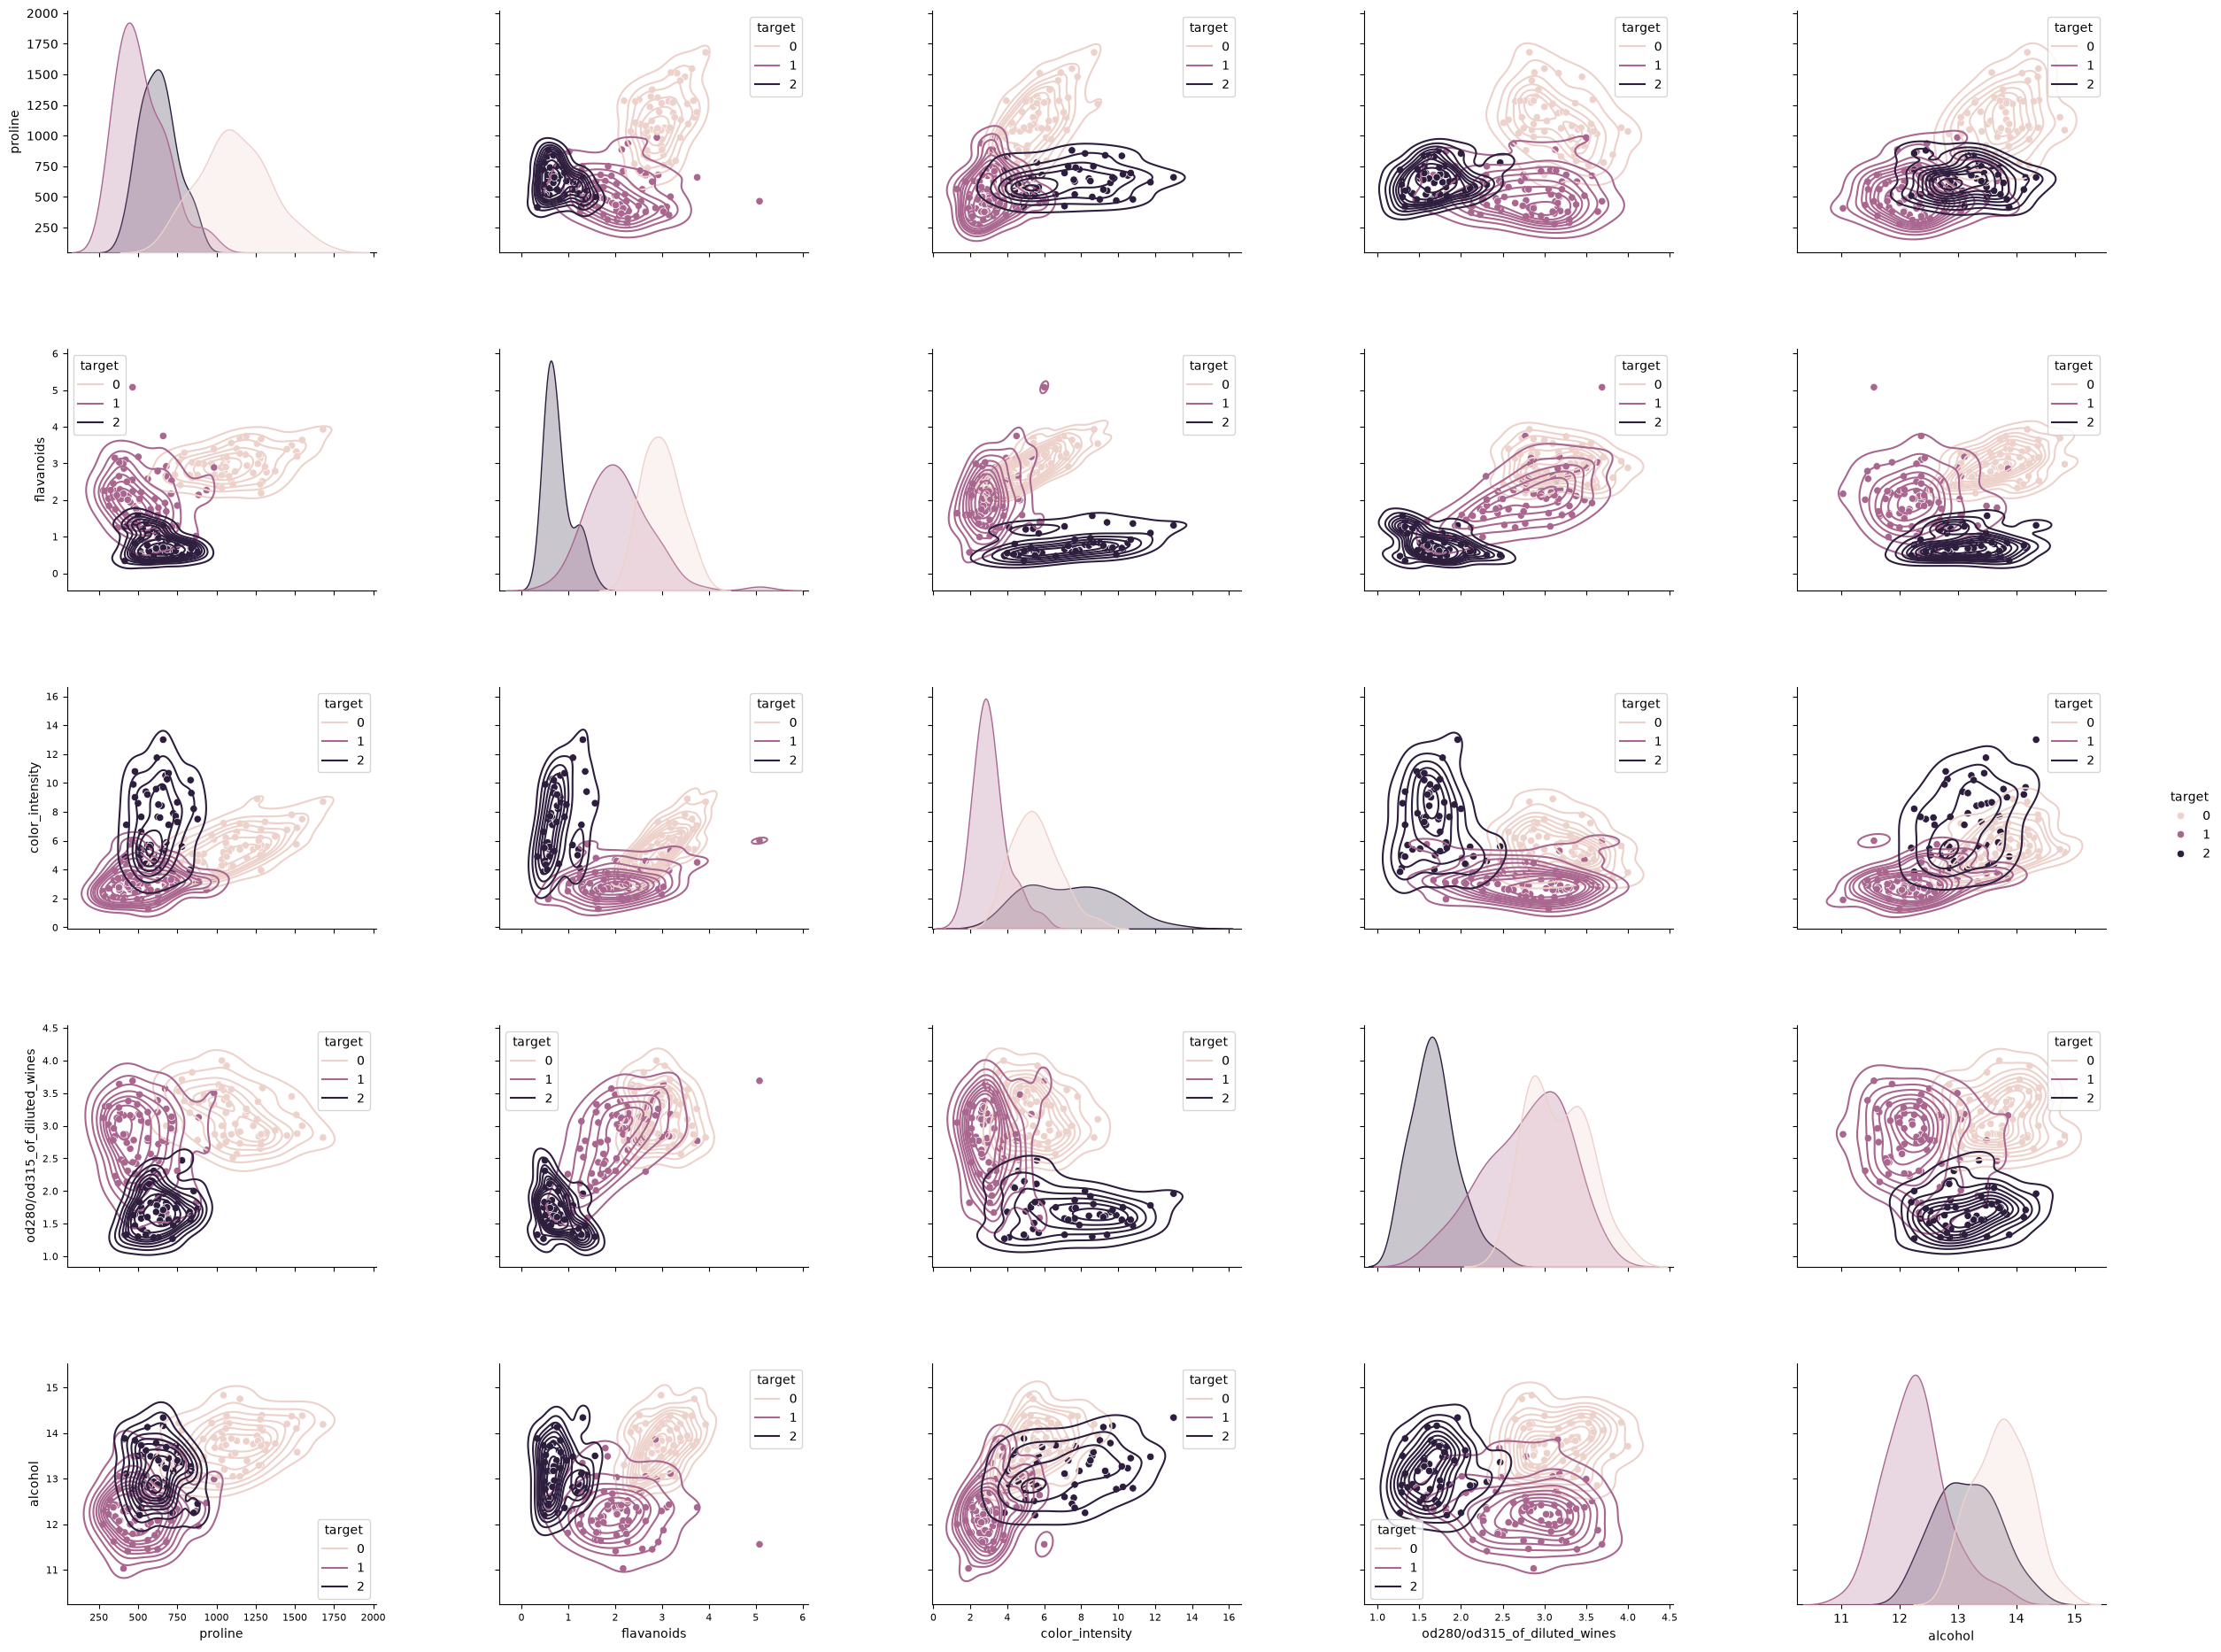

In [232]:
# Solution 2


# Using Pairplot
import seaborn as sns
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt

# Load the wine dataset
data = load_wine(as_frame=True).frame
wine = data[['proline', 'flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'alcohol', 'target']]
# Define the pairplot with 2D KDE plots
g = sns.pairplot(wine, hue='target', diag_kind='kde', height=4, aspect=1.25)

# Add 2D KDE plots to all other subplots
for ax in g.axes.flat:
    if ax.get_xlabel() != "" and ax.get_ylabel() != "":
        sns.kdeplot(data=wine, x=ax.get_xlabel(), y=ax.get_ylabel(), hue='target', ax=ax)
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)
        ax.set_ylabel(ax.get_ylabel(), fontsize=10)
        ax.tick_params(labelsize=8)

# Adjust the layout
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.4, wspace=0.4)

# Show the plot
plt.show()


# Based on 2D KDE plot - proline and od280/od315_of_diluted_wines making best feature


# 3 classes are less overlapped 

<Axes: xlabel='proline', ylabel='od280/od315_of_diluted_wines'>

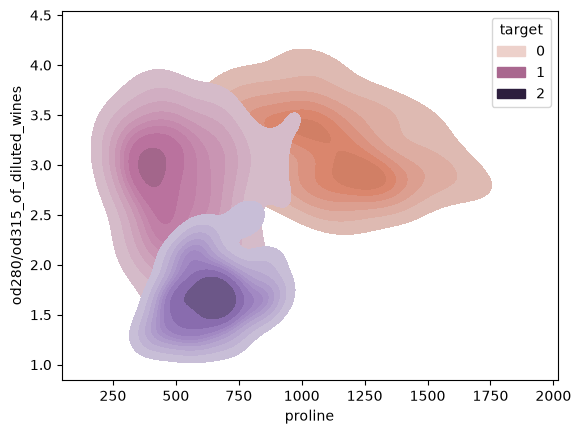

In [233]:
sns.kdeplot(data=wine, x='proline', y='od280/od315_of_diluted_wines', hue='target', fill=True)

`Note`

⚛ Class_2 : diluted_wines < 2.4 and proline < 950

⚛ Class_1 : diluted_wines > 2.4 and proline < 950

⚛ Class_0 : diluted_wines > 2.4 and proline > 950

<Axes: xlabel='flavanoids', ylabel='alcohol'>

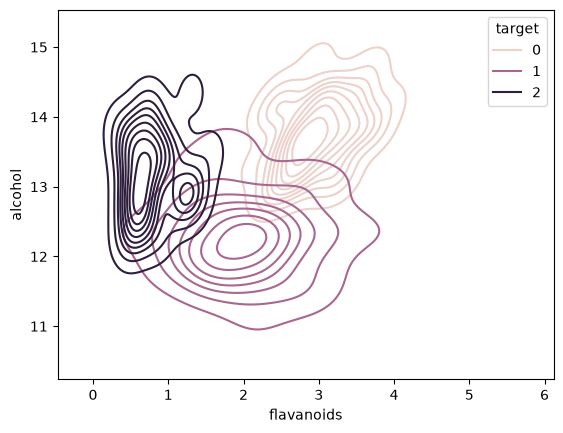

In [234]:
sns.kdeplot(data=wine, x='flavanoids', y='alcohol', hue='target')